## Instalção dos pacotes básicos

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
import time

## Questão A

### Função para jogar dado

Essa função irá escolher aleatoriamente o número de jogadas e irá adicionar a frequência que elas caíram dentro de um vetor para serem usadas posteriormente.

In [2]:
def simulate_throws(probabilities: list[float], throws: int = 100, seed: int | None = None) -> list[float]:
    generator = np.random.default_rng(seed)
    faces: list[int] = [1, 2, 3, 4, 5, 6]
    results: np.ndarray = generator.choice(faces, p=probabilities, size=throws)

    empirical_probs: list[float] = []
    for i in range(1, 7):
        count: int = np.sum(results == i) # transform to boolean array
        empirical_probs.append(count / throws)

    return empirical_probs

### Função para calcular a entropia

A entropia mede o grau de incerteza/desordem de uma única distribuição. Desse modo, ele indica qual a surpresa média do sistema observado.

$$
-\sum_i^n{p_i \log{p_i}}
$$

Obs: quando $p_i$ é igual a 0 o valor será desconsiderado para não dar erro no cálculo. Ou seja, ele será considerado como $0$.

In [3]:
def calculate_entropy(probabilities: list[float]) -> float:
    return -sum(p * math.log2(p) for p in probabilities if p > 0)

### Função para calcular a cross entropia

Essa função busca encontrar a relação entre a entropia identificada pelo modelo e a entropia real. Essa função é muito útil para avaliar o desempenho do modelo em relação aos dados de teste.

Sua fórmula é dada por:

$$
H(P, Q) = \sum_i^n{p_i \log{q_i}}
$$

Sendo $q_i$ a entropia do modelo e $p_i$ a entropia da distribuição real.

In [4]:
def calculate_cross_entropy(probs_p: list[float], probs_q: list[float]) -> float:
    return -sum(p * math.log2(q) for p, q in zip(probs_p, probs_q) if p > 0 and q > 0)

### Decaimento exponencial

Essa técnica é muito útil para diminuir o _learning rate_ do modelo conforme ele se aproxima a solução ideal, melhorando a convergência do mesmo. No nosso caso, estamos utilizando para aos poucos ir convergindo para o nosso objetivo de idealizar as probabilidades das faces do dado.

Sua fórmula pode ser baseada em uma taxa de erro:

$$
\delta_x = p_{\text{atual}} - p_{\text{objetivo}}
$$

E esse erro é usado na fórmula:

$$
E(x) = p_{\text{objetivo}} + \delta_x e^{-k}
$$

Onde cada símbolo pode ser traduzido para o problema da seguinte forma:

- $x$ : Face do dado que estamos analisando
- $E(x)$ : Nova probabilidade em ralação a $x$
- $p_{\text{objetivo}}$ : Probabilidade ideal que desejamos alcançar
- $p_{\text{atual}}$ : Probabilidade atual da face
- $\delta_x$ : Erro entre a probabilidade atual e a ideal
- $k$ : Taxa de decaimento. Define o quanto irá dacair com base em valores constantes

In [5]:
def exponential_decay(objective: float, decay_rate: float, probabilities: list[float]) -> list[float]:
    new_probs: list[float] = probabilities.copy()

    # index 0 represents face 1
    # index 5 represents face 6
    err1: float = new_probs[0] - objective
    err6: float = new_probs[5] - objective

    new_probs[0] = objective + (err1 * math.exp(-decay_rate))
    new_probs[5] = objective + (err6 * math.exp(-decay_rate))

    # recalculate remaining faces to ensure probabilities sum to 1.0
    rest: float = 1.0 - new_probs[0] - new_probs[5]
    rest_per_side: float = rest / 4.0

    for i in range(1, 5):
        new_probs[i] = rest_per_side

    return new_probs

### Função do experimento para avaliação

In [8]:
def run_calibration_experiment(iterations: int = 30):
    # initial setup
    probabilities_fake: list[float] = [0.25, 0.125, 0.125, 0.125, 0.125, 0.25]
    probabilities_fair: list[float] = [1/6] * 6

    # initial experiment: simulate 100 throws
    empirical_probs: list[float] = simulate_throws(probabilities_fake, throws=100)
    empirical_entropy = calculate_entropy(empirical_probs)
    print(f"Entropia Empírica (100 throws): {empirical_entropy}")
    print(f"Entropia Teórica Inicial: {calculate_entropy(probabilities_fake)}")

    # calibration process
    decay_rate = 0.2 # determines how fast the die converges per iteration
    current_probs = probabilities_fake.copy()

    history_entropy = []
    history_cross_entropy = []

    for i in range(iterations):
        ent: float = calculate_entropy(current_probs)
        ce: float = calculate_cross_entropy(current_probs, probabilities_fair)

        history_entropy.append(ent)
        history_cross_entropy.append(ce)

        current_probs = exponential_decay(1/6, decay_rate, current_probs)

    # plotting the metrics
    plt.figure(figsize=(9, 5))
    plt.plot(history_entropy, label='Entropia $H(P)$', color='blue', linewidth=2.5)
    plt.plot(history_cross_entropy, label='Cross-Entropy $H(P, Q)$', color='purple', linewidth=2.5)

    plt.title('Entropia vs Cross-Entropia', fontsize=14)
    plt.xlabel('Iteração de Calibragem', fontsize=12)
    plt.ylabel('Bits', fontsize=12)

    # target entropy line for a fair die (log2(6))
    # all sides must have the same probability
    fair_entropy = math.log2(6)
    plt.axhline(y=fair_entropy, color='black', linestyle=':', label=f'Alvo (Dado justo) ≈ {fair_entropy}')

    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

Entropia Empírica (100 throws): 2.4241933957278894
Entropia Teórica Inicial: 2.5


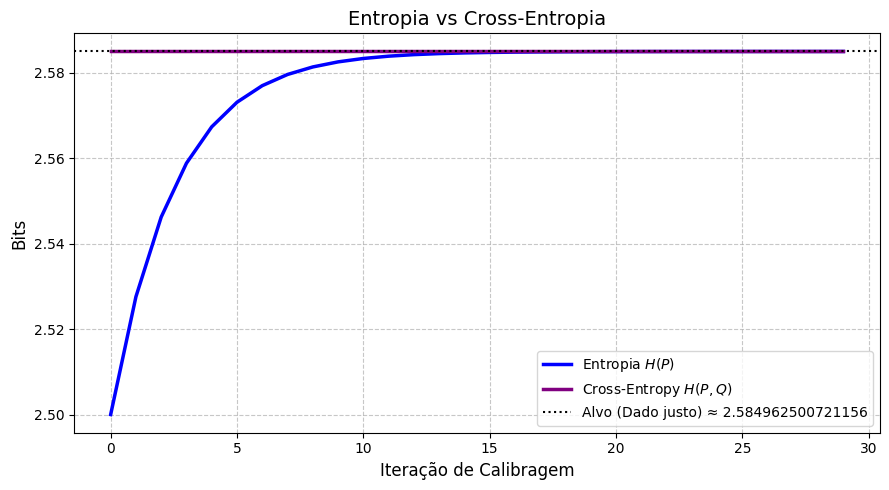

In [9]:
run_calibration_experiment()

## Questão B

### Criação da função de probabilidade

Essa função fica responsável por criar uma simulação de jogadas de moeda em que será definido a probabilidade de cair cara. Ela adiciona o número de vezes que caiu cara e o número de vezes que caiu coroa

In [ ]:
def throw_coins(runs: int, probabilities: list[float], seed: int | float | None = None) -> list[int]:
    """
    Throw a coin (or an n-sided object) runs times with specified probabilities.

    Args:
        runs (int): Number of throws.
        probabilities (list[float]): List of probabilities for each outcome.

    Returns:
        list[int]: The count of occurrences for each outcome.
    """
    # the sum must be equals to 1.0
    if not math.isclose(sum(probabilities), 1.0):
        raise RuntimeError(f"Error: probabilities must sum to 1.0. Got {sum(probabilities)}")

    generator = np.random.default_rng(seed) # type: ignore

    # gen a array with faces
    faces: np.ndarray = np.arange(len(probabilities))

    # choice a face with the provided probabilities
    results: np.ndarray = generator.choice(faces, p=probabilities, size=runs)

    # count throws results
    counts: list[int] = [np.sum(results == i) for i in range(len(probabilities))] # array like a distribution
    return counts

In [ ]:
result: list[int] = throw_coins(1000, [0.5, 0.5])
print(result)

### Criação da função para calcular a surpresa média

A surpresa média calcula o quão improvável era de acontecer a distribuição calculada. Esse cálculo é importante para entender se o treinamento reflete bem os dados de treino. Assim, o cálculo baseando na amostragem escolhida revela o quão próximo foi de alcaçar o valor teórico que seria o esperado com muitas simulações.

A fórmula da surpresa média é:

$$
\sum_{s}{p_s \log{\frac{1}{p_s}}}
$$

In [ ]:
def calculate_avg_coin_surprise(coin_results: list[int]) -> float:
    total_throws: int = sum(coin_results)
    total_surprise: float = 0.0

    for count in coin_results:
        # avoid division by 0
        if count == 0:
            continue

        prob: float = count / total_throws
        total_surprise += prob * np.log2(1 / prob)

    return total_surprise

In [ ]:
calculate_avg_coin_surprise(result)

### Criando a função para gerar as simulações e criar os gráficos

In [ ]:
def run_experiment_and_plot_all():
    runs_to_test = [10, 100, 1000]

    coins: dict[str, list[float]] = {
        "Justa (50/50)": [0.5, 0.5],
        "Viciada (90/10)": [0.9, 0.1],
        "Slide (49/49/2)": [0.49, 0.49, 0.02]
    }

    x: np.ndarray = np.arange(len(coins))
    width: float = 0.2
    fig, ax = plt.subplots(figsize=(12, 6))

    offsets = [-1.5, -0.5, 0.5, 1.5]
    labels = ["10 Runs", "100 Runs", "1000 Runs", "Teórico"]
    colors = ['yellow', 'gold', 'red', 'purple']

    for i, (runs_label, offset, color) in enumerate(zip(labels, offsets, colors)):
        values: list[float] = []
        for name, probs in coins.items():
            if runs_label == "Teórico":
                # calculate with the formula
                val: float = sum(p * np.log2(1 / p) for p in probs if p > 0)
            else:
                # calculate the average surprise iterative
                runs = runs_to_test[i]
                results: list[int] = throw_coins(runs, probabilities=probs)
                val: float = calculate_avg_coin_surprise(results)
            values.append(val)

        # move the bar to right
        rects = ax.bar(x + offset * width, values, width, label=runs_label, color=color, edgecolor='black', alpha=0.9)

        for rect in rects:
            height: float = rect.get_height()
            ax.annotate(f'{height:.4f}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3),
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=8, fontweight='bold')

    ax.set_ylabel('Surpresa Media / Entropia', fontsize=12)
    ax.set_title('Surpresa Media vs. Número de Jogadsa para Multiplas Moedas', fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels(coins.keys(), fontsize=11)
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

### Mostrando os resultados das simulações

Desse modo, fica evidente o quanto o número de simulações aproxima do esperado teórico calculado. Esse fenômeno pode ser explicado pela lei dos grandes números, onde o aumento da amostra aproxima do valor teórico real.

Ou seja, enquanto o resultado esperado para a moeda justa se aproxime de uma entropia máxima para um sistema binário, pois fica muito difícil de prever qual seria o próximo lançamento provável. Por outro lado, numa moeda injusta a surpresa é maior, pois o valor já é esperado

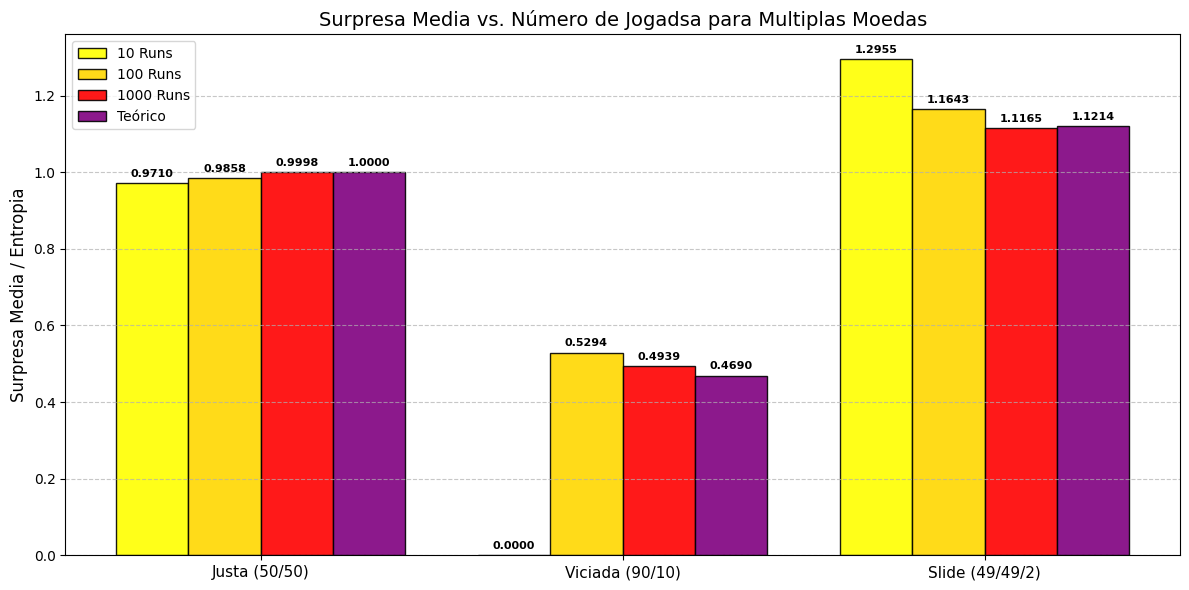

In [ ]:
run_experiment_and_plot_all()

## Questão C

### Softmax

Essa função serve para normalizar os dados utilizando um cálculo exponencial. Normalmente é utilizada em redes neurais.

[slides](https://docs.google.com/presentation/d/19M4RF5SyVnQTJpnEmCvyqa7jA5qZyCg_Dl7UV9ZCPtU/edit?usp=sharing)

In [10]:
def softmax(logits: np.ndarray) -> np.ndarray:
    exp_logits: np.ndarray = np.exp(logits - np.max(logits, axis=-1, keepdims=True))
    return exp_logits / np.sum(exp_logits, axis=-1, keepdims=True)

### Perda da cross entropia

Para evitar erros, foi colocado um epsilon minúsculo para não afetar o cálculo e não ocorrer $\log({0})$ que seria matematicamente impossível.

In [11]:
def cross_entropy_loss(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    # compute the cross-entropy loss for a multi-class classification problem
    # epsilon is added to prevent log(0) undefined errors during execution
    epsilon: float = 1e-15
    y_pred = np.clip(y_pred, epsilon, 1.0 - epsilon) # avoid log(0) and log(1)

    # Returns the mean entropy loss across all samples
    return -np.sum(y_true * np.log(y_pred)) / y_true.shape[0]

### Execução do experimento

O experimento irá utilizar um gerador pseudoaleatório com o horário do sistema como _seed_ e irá entrar dentro do _loop_ principal. Cada iteração vai buscar sempre o melhor _logit_ e utilizar ele para a próxima iteração até o limite de iterações estabelecido for encontrado.

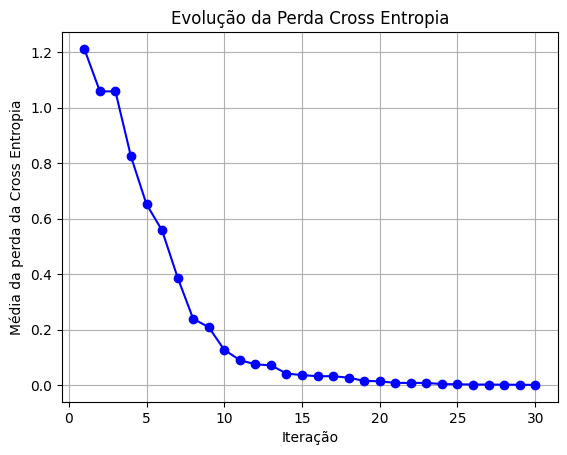

In [12]:
# use the seed generated from the system clock
np.random.seed(int(time.time()))

# true labels (one-hot encoded) for the three samples
true_labels: np.ndarray = np.array([
    [1, 0, 0],
    [0, 1, 0],
    [0, 0, 1]
])

# first output generation
# generating raw logits randomly between 0.1 and 3.0
current_logits: np.ndarray = np.random.uniform(0.1, 3.0, (3, 3))

std_dev: float = 0.5  # standard deviation defined as a hyperparameter
num_iterations: int = 30  # repeat 30 times
loss_history: list = []

# main loop
for iteration in range(num_iterations):
    # start the candidate pool with the current logits
    candidates: list[np.ndarray] = [current_logits]

    # generate four other sequences using a Gaussian distribution
    # the current raw logits act as the mean
    for _ in range(4):
        noise: float = np.random.normal(loc=0.0, scale=std_dev, size=current_logits.shape)
        candidates.append(current_logits + noise)

    evaluated_candidates: list[tuple[float, np.ndarray]] = []

    # apply softmax and calculate the cross-entropy loss for each candidate
    for cand_logits in candidates:
        cand_probs: np.ndarray = softmax(cand_logits)
        cand_loss: float = cross_entropy_loss(true_labels, cand_probs)
        evaluated_candidates.append((cand_loss, cand_logits))

    # order the sequences based on mean entropy
    # ascendent order
    evaluated_candidates.sort(key=lambda x: x[0])

    # keep the best sequence and implicitly discard the 4 worst
    best_loss, best_logits = evaluated_candidates[0]


    current_logits = best_logits
    loss_history.append(best_loss)

# show the evolution of entropy with the number of iterations
plt.plot(range(1, num_iterations + 1), loss_history, marker='o', linestyle='-', color='b')
plt.title('Evolução da Perda Cross Entropia')
plt.xlabel('Iteração')
plt.ylabel('Média da perda da Cross Entropia')
plt.grid(True)
plt.show()

## Qustão D

### Logits

Logits são dados não tratados resultantes das inferências

### Softmax

É uma função utilizada para normalizar os dados, deixando a soma deles igual ao valor 1. Normalmente é utilizada como função de ativação em redes neurais.

In [13]:
def softmax_outcomes(logits: dict[str, float]) -> dict[str, float]:
  sum_total_logits: float = sum(math.exp(value) for value in logits.values())
  new_logits: dict[str, float] = {}

  for key, value in logits.items():
      new_logits[key] = math.exp(value) / sum_total_logits

  return new_logits

### Comparação

Ao comparar com o resultado que seria o ideal $0 = (1, 0, 0)$ nota-se que a IA tem quase que 94% de certeza que a imagem deve ser classificada como "urbano". Isso demonstra que ela está muito distante do valor real que deveria atingir.

### Motivo de decair em: $-\ln{q_{floresta}}$

A fórmula da entropia cruzada porde ser representada como:

$$
H(P, Q) = \sum_i^n{p_i \ln{\frac{1}{q_i}}}
$$

Sendo $p$ e $q$, respectivamente, os valores da distribuição escolhida e o $q$ o valor obtido pelo experimento. Logo, como são apenas 3 classes, o valor de $n$ vira apenas $3$. Podemos reescrever o somatório da seguinte forma:

$$
H(P, Q) = p_{floresta} \ln{\frac{1}{q_{floresta}}} + p_{água} \ln{\frac{1}{q_{água}}} + p_{urbano} \ln{\frac{1}{q_{urbano}}}
$$

Entretanto, como visto na distribuição correta: $p = (1, 0, 0)$, os valores de $p_{água}$ e $p_{urbano}$ irão ser multiplicados por $0$, anulando-os. E $p_{floresta}$ irá apenas conservar a sua multiplicação, por ele ser o número $1$.

$$
H(P, Q) = 1 \ln{\frac{1}{q_{floresta}}}
$$

Removendo a fração de dentro do log, podemos obter a seguinte expressão:

$$
H(P, Q) = -\ln{q_{floresta}}
$$

In [14]:
logits: dict[str, float] = {
    "floresta": 2.0,
    "água": 1.0,
    "urbano": 5.0
}

softmax_outcomes(logits)

{'floresta': 0.04661262257797389,
 'água': 0.01714782554552039,
 'urbano': 0.9362395518765058}

## Experimentando um pseudo backpropagation

Conforme o esperado, quando os demais valores começam a reduzir e o valor de "floresta" cresce, o softmax aproxima-se da distribuição: $p = (1, 0, 0)$. Esse processo evidencia o aprendizado da máquina, embora seja apenas uma simulação nesse exemplo.

In [15]:
for current_logits in [
    {
      "floresta": 2.0,
      "água": 1.0,
      "urbano": 5.0
    },
    {
      "floresta": 2.5,
      "água": 0.75,
      "urbano": 4.0
    },
    {
      "floresta": 3.0,
      "água": 0.5,
      "urbano": 3.0
    },
    {
      "floresta": 3.5,
      "água": 0.25,
      "urbano": 2.0
    },
    {
      "floresta": 4.0,
      "água": 0.0,
      "urbano": 1.0
    },
    {
      "floresta": 4.5,
      "água": 0.0,
      "urbano": 0.0
    },
]:
  print(softmax_outcomes(current_logits))

{'floresta': 0.04661262257797389, 'água': 0.01714782554552039, 'urbano': 0.9362395518765058}
{'floresta': 0.1768201821074443, 'água': 0.030726740326436436, 'urbano': 0.7924530775661193}
{'floresta': 0.48028778876026895, 'água': 0.039424422479462075, 'urbano': 0.48028778876026895}
{'floresta': 0.7924530775661193, 'água': 0.030726740326436432, 'urbano': 0.1768201821074443}
{'floresta': 0.9362395518765056, 'água': 0.01714782554552039, 'urbano': 0.04661262257797389}
{'floresta': 0.9782649168504489, 'água': 0.010867541574775536, 'urbano': 0.010867541574775536}


## Questão E

### Função para cálculo do valor esperado

Essa função busca encontrar exatamente o valor esperado baseado na população (_counts_ fornecidos) e os _outcomes_ discretos.

In [16]:
def calculate_expected_value(counts: dict[str, int], outcomes: dict[str, float]) -> float:
    """
    Calculates the exact Expected Value (EV) based on population counts and discrete outcomes.

    Args:
        counts (dict[str, int]): A dictionary with the raw counts for each event.
        outcomes (dict[str, float]): A dictionary with the payout/outcome for each event.

    Returns:
        float: The theoretical expected value.
    """
    total_population: int = sum(counts.values())
    expected_value: float = 0.0

    for key in counts:
        probability = counts[key] / total_population
        expected_value += probability * outcomes[key]

    return expected_value

### Criação da função de simulação

Essa função recebem os _outcomes_ do slide 51 e os dados (_counts_) do slide 26. Ela irá demonstrar o quanto irá aproximar-se o valor esperado empírico do valor teórico conforme o número de amostras cresce.

No contexto dessa questão, os dados de entrada (_counts_) são os dados de pessoas que assistiram ao filme Troll 2, sendo a nossa base de dados que usaremos. Já os _outcomes_ representam a classificação de cada grupo para representar seu valor.

A partir disso, utilizando a probabilidade esperada, nós podemos inferir qual classificação (_outcome_) se enquadra melhor para a situação.

In [17]:
def run_expected_value_simulation():
    slide_26_counts: dict[str, int] = {
        "heard": 37,
        "never_heard": 176
    }

    slide_51_outcomes: dict[str, float] = {
        "heard": -1.0,
        "never_heard": 1.0
    }

    theoretical_ev = calculate_expected_value(slide_26_counts, slide_51_outcomes)
    print(f"Valor esperado teórico: {theoretical_ev:.5f}")

    total_pop = sum(slide_26_counts.values())
    probabilities = [
        slide_26_counts["heard"] / total_pop,
        slide_26_counts["never_heard"] / total_pop
    ]
    outcome_values = [
        slide_51_outcomes["heard"],
        slide_51_outcomes["never_heard"]
    ]

    repetitions_list = [10, 100, 1000, 10000]
    empirical_evs = []

    rng = np.random.default_rng()

    print("-" * 40)
    for reps in repetitions_list:
        simulated_results = rng.choice(outcome_values, p=probabilities, size=reps)

        empirical_mean = np.mean(simulated_results)
        empirical_evs.append(empirical_mean)

        print(f"Empirical EV for {reps:>5} repetitions: {empirical_mean:.5f}")

### Execução e avaliação

Como pode ser observado, o valor empírico irá aproximar-se do valor teórico conforme as amostras aumentam, resultando em valores mais precisos. Novamente essa aproximação ocorre devido a lei dos grandes números

In [18]:
run_expected_value_simulation()

Valor esperado teórico: 0.65258
----------------------------------------
Empirical EV for    10 repetitions: 0.80000
Empirical EV for   100 repetitions: 0.54000
Empirical EV for  1000 repetitions: 0.66600
Empirical EV for 10000 repetitions: 0.64280
